# DataTrove Graduate Placement Programme
## Task 3C — Data Science Libraries

**Issued by:** Promise Ekeh, Head of Analytics  
**Phase:** 1 — Onboarding & Foundations  
**Task:** 3C — NumPy, pandas, matplotlib & seaborn

---

You've made it to the libraries. This is where Python becomes data science.

In this task you will work with the four core libraries used by every data analyst and data scientist:

| Library | What it does |
|---|---|
| **NumPy** | Fast numerical computation with arrays |
| **pandas** | Load, explore, clean, and analyse tabular data |
| **matplotlib** | Build charts and visualisations |
| **seaborn** | Beautiful statistical charts with less code |

You will be working with the **DataTrove Nigerian operations dataset** — the same sales data you received in Task 2, now contextualised for our Nigerian cities.

Run the setup cell first, then work through each part in order.  
Push the completed notebook to your `datatrove-placement` repo.

— Promise Ekeh

---
## Setup — Run This First

In [1]:
# These libraries should already be installed in your virtual environment (Task 3B).
# If an import below fails, activate your venv, run `pip install -r requirements.txt`,
# and make sure that venv is selected as this notebook's kernel.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all seaborn charts
sns.set_theme(style="whitegrid")

print("NumPy:      ", np.__version__)
print("pandas:     ", pd.__version__)
print("matplotlib: ", plt.matplotlib.__version__)
print("seaborn:    ", sns.__version__)
print("\nAll libraries loaded successfully!")

Matplotlib is building the font cache; this may take a moment.


NumPy:       2.4.6
pandas:      3.0.3
matplotlib:  3.10.9
seaborn:     0.13.2

All libraries loaded successfully!


---
## Dataset — `datatrove_sales_2024.csv`

The **DataTrove 2024 sales export** used throughout Parts 2–4 lives in the project's `dataset/` folder as `datatrove_sales_2024.csv`. It has been provided to you — make sure that file is in the `dataset/` folder before you start.

The dataset has **500 rows** and these columns:

| Column | Type | Description |
|---|---|---|
| `order_id` | text | Unique order reference (e.g. `DT-20240001`) |
| `order_date` | date | Order date in 2024 (`YYYY-MM-DD`) |
| `city` | text | Nigerian city the order came from |
| `category` | text | Product category |
| `product_name` | text | Name of the product sold |
| `quantity` | integer | Units sold in the order |
| `unit_price` | float | Price per unit, in Naira (₦) |
| `discount_pct` | integer | Discount applied (0–20%) |
| `total_amount` | float | Final amount after discount, in Naira (₦) |
| `customer_id` | text | Customer reference |
| `return_flag` | text | `Y` if the order was returned, otherwise `N` |
| `sales_channel` | text | `Online`, `In-Store`, `Phone`, or `Marketplace` |
| `payment_method` | text | Payment type — **some values are intentionally missing** |

> Note: `payment_method` contains some missing values on purpose, so the data-quality questions in Part 2 (missing values, filtering nulls) are realistic.

---
# Part 1 — NumPy

*NumPy (Numerical Python) is the foundation of data science in Python. It provides the **array** — a fast, efficient structure for numerical computation. pandas is built directly on top of NumPy.*

## Question 1.1 — Written

What is NumPy and why is it faster than regular Python lists for numerical data?  
What is a NumPy array? Give **two** key differences between a NumPy array and a Python list.

## What is NumPy?
NumPy is a Python library used for numerical computing. It provides fast and efficient operations on arrays and is widely used in data science.

## Why is it faster than Python lists?
NumPy is faster because it is implemented in optimized C code and stores data in contiguous memory, allowing efficient computation.

## What is a NumPy array?
A NumPy array is a data structure that stores elements of the same data type and allows fast mathematical operations.

## Two differences between NumPy arrays and Python lists:
NumPy arrays store a single data type, while Python lists can store multiple data types
NumPy arrays support vectorized operations, that is, no loops needed, while Python lists require loops.

## Question 1.2 — Code

Create NumPy arrays from DataTrove's Nigerian city sales and price data:

```python
city_sales  = [47800, 28400, 14200, 21500, 16300, 11200, 13600, 9800, 8700, 7500]
unit_prices = [49.99, 129.99, 34.99, 24.99, 39.99, 79.99, 54.99, 29.99, 19.99, 89.99]
```

For each array, print:
1. The array itself
2. Its `shape`, `dtype`, and `size`
3. The `sum`, `mean`, `min`, `max`, and standard deviation (`std`)
4. All values **above** the mean (using boolean indexing)

In [5]:
import numpy as np

city_sales  = np.array([47800, 28400, 14200, 21500, 16300, 11200, 13600, 9800, 8700, 7500])
unit_prices = np.array([49.99, 129.99, 34.99, 24.99, 39.99, 79.99, 54.99, 29.99, 19.99, 89.99])

# CITY SALES
print("CITY SALES:")
print(city_sales)

print("Shape:", city_sales.shape)
print("Data type:", city_sales.dtype)
print("Size:", city_sales.size)

print("Sum:", city_sales.sum())
print("Mean:", city_sales.mean())
print("Min:", city_sales.min())
print("Max:", city_sales.max())
print("Std Dev:", city_sales.std())

print("Above mean:")
print(city_sales[city_sales > city_sales.mean()])


print("\n-------------------\n")

# UNIT PRICES
print("UNIT PRICES:")
print(unit_prices)

print("Shape:", unit_prices.shape)
print("Data type:", unit_prices.dtype)
print("Size:", unit_prices.size)

print("Sum:", unit_prices.sum())
print("Mean:", unit_prices.mean())
print("Min:", unit_prices.min())
print("Max:", unit_prices.max())
print("Std Dev:", unit_prices.std())

print("Above mean:")
print(unit_prices[unit_prices > unit_prices.mean()])

CITY SALES:
[47800 28400 14200 21500 16300 11200 13600  9800  8700  7500]
Shape: (10,)
Data type: int64
Size: 10
Sum: 179000
Mean: 17900.0
Min: 7500
Max: 47800
Std Dev: 11641.56346888166
Above mean:
[47800 28400 21500]

-------------------

UNIT PRICES:
[ 49.99 129.99  34.99  24.99  39.99  79.99  54.99  29.99  19.99  89.99]
Shape: (10,)
Data type: float64
Size: 10
Sum: 554.9
Mean: 55.489999999999995
Min: 19.99
Max: 129.99
Std Dev: 32.9734741875951
Above mean:
[129.99  79.99  89.99]


## Question 1.3 — Code

DataTrove processes these order quantities, prices, and discounts across Nigerian cities:

```python
quantities  = np.array([3, 1, 5, 2, 4, 1, 3, 2, 6, 2])
unit_prices = np.array([49.99, 129.99, 34.99, 24.99, 39.99, 79.99, 54.99, 29.99, 19.99, 89.99])
discounts   = np.array([10, 0, 15, 5, 10, 20, 0, 5, 0, 10])
```

Write code that:
1. Calculates **gross revenue** per order (quantity × price) using array multiplication
2. Calculates the **discount amount** per order
3. Calculates the **net total** per order after discount
4. Finds the index of the highest net order using `np.argmax()`
5. Prints all orders where the net total exceeds ₦100

In [6]:
quantities  = np.array([3, 1, 5, 2, 4, 1, 3, 2, 6, 2])
unit_prices = np.array([49.99, 129.99, 34.99, 24.99, 39.99, 79.99, 54.99, 29.99, 19.99, 89.99])
discounts   = np.array([10, 0, 15, 5, 10, 20, 0, 5, 0, 10])

# Gross revenue
gross = quantities * unit_prices

# Discount amount
discount_amount = gross * (discounts / 100)

# Net total
net = gross - discount_amount

print("Gross:", gross)
print("Discount:", discount_amount)
print("Net:", net)

# Highest order
print("Index of highest net order:", np.argmax(net))

# Orders above 100
print("Orders above 100:")
print(net[net > 100])

Gross: [149.97 129.99 174.95  49.98 159.96  79.99 164.97  59.98 119.94 179.98]
Discount: [14.997   0.     26.2425  2.499  15.996  15.998   0.      2.999   0.
 17.998 ]
Net: [134.973  129.99   148.7075  47.481  143.964   63.992  164.97    56.981
 119.94   161.982 ]
Index of highest net order: 6
Orders above 100:
[134.973  129.99   148.7075 143.964  164.97   119.94   161.982 ]


## Question 1.4 — Code ⭐ Challenge

Analyse quarterly sales data across Nigerian cities using a 2D NumPy array:

```python
quarterly_sales = np.array([
    [12000, 15000,  9000, 21000],   # Lagos
    [11000, 14500,  8500, 19000],   # Abuja
    [ 5500,  6000,  4800,  7200],   # Kano
    [ 8000,  9500,  7000, 11000],   # Port Harcourt
    [ 6300,  7100,  5500,  8400],   # Ibadan
])
# Rows = cities, Columns = Q1, Q2, Q3, Q4
```

Write code that:
1. Prints the shape and confirms what each dimension represents
2. Calculates **total annual sales** per city (sum each row)
3. Calculates **total sales** per quarter (sum each column)
4. Finds the best-performing city overall
5. Finds the strongest quarter overall
6. Calculates the **quarter-on-quarter percentage change** for Lagos (row 0)
7. Prints a formatted summary report of findings

In [7]:
quarterly_sales = np.array([
    [12000, 15000,  9000, 21000],
    [11000, 14500,  8500, 19000],
    [ 5500,  6000,  4800,  7200],
    [ 8000,  9500,  7000, 11000],
    [ 6300,  7100,  5500,  8400],
])

cities    = ["Lagos", "Abuja", "Kano", "Port Harcourt", "Ibadan"]
quarters  = ["Q1", "Q2", "Q3", "Q4"]

# Shape
print("Shape:", quarterly_sales.shape)

# Total per city
city_totals = quarterly_sales.sum(axis=1)
print("Total per city:", city_totals)

# Total per quarter
quarter_totals = quarterly_sales.sum(axis=0)
print("Total per quarter:", quarter_totals)

# Best city
print("Best city:", cities[np.argmax(city_totals)])

# Best quarter
print("Best quarter:", quarters[np.argmax(quarter_totals)])

# Lagos growth
lagos = quarterly_sales[0]
growth = (lagos[1:] - lagos[:-1]) / lagos[:-1] * 100
print("Lagos QoQ growth:", growth)

Shape: (5, 4)
Total per city: [57000 53000 23500 35500 27300]
Total per quarter: [42800 52100 34800 66600]
Best city: Lagos
Best quarter: Q4
Lagos QoQ growth: [ 25.         -40.         133.33333333]


---
# Part 2 — pandas

*pandas is the most important tool in your data science toolkit. The DataFrame gives you a table-like structure to load, explore, filter, clean, group, and analyse data. The entire rest of this placement will use pandas.*

## Question 2.1 — Written

What is a pandas **DataFrame**? Describe how it relates to:
- A Python dictionary
- A NumPy array
- A spreadsheet

What is a pandas **Series** and how does it relate to a DataFrame?

## What is a pandas DataFrame?
A pandas DataFrame is a table-like data structure used to store and manipulate data in rows and columns.

## It's relationship to:
## Python dictionary:
A DataFrame is like a dictionary of lists, where each key is a column name and the values are the column data.
## NumPy array:
A DataFrame is built on top of NumPy arrays, meaning it uses NumPy for fast computations.
## Spreadsheet:
A DataFrame is similar to an Excel spreadsheet, with rows and columns that can be sorted, filtered, and analysed.

## What is a pandas Series?
A Series is a single column of data in a DataFrame.
A DataFrame is made up of multiple Series.

## Question 2.2 — Code — Build a DataFrame from Scratch

Create a DataFrame from this DataTrove Nigerian sales data:

```python
data = {
    "order_id":    ["DT-001", "DT-002", "DT-003", "DT-004", "DT-005", "DT-006"],
    "city":        ["Lagos", "Abuja", "Kano", "Lagos", "Port Harcourt", "Ibadan"],
    "category":    ["Electronics", "Clothing", "Electronics", "Home & Garden", "Food & Drink", "Electronics"],
    "quantity":    [3, 1, 2, 4, 2, 5],
    "unit_price":  [49.99, 89.99, 129.99, 24.99, 12.99, 39.99],
    "discount_pct":[10, 0, 15, 5, 0, 10],
}
```

Then:
1. Display the DataFrame
2. Print its `shape`, `columns`, and `dtypes`
3. Add a `total_amount` column calculated from the other columns
4. Display summary statistics with `.describe()`
5. Show the first 3 rows with `.head(3)` and last 2 with `.tail(2)`

In [16]:
import pandas as pd

data = {
    "order_id":    ["DT-001", "DT-002", "DT-003", "DT-004", "DT-005", "DT-006"],
    "city":        ["Lagos", "Abuja", "Kano", "Lagos", "Port Harcourt", "Ibadan"],
    "category":    ["Electronics", "Clothing", "Electronics", "Home & Garden", "Food & Drink", "Electronics"],
    "quantity":    [3, 1, 2, 4, 2, 5],
    "unit_price":  [49.99, 89.99, 129.99, 24.99, 12.99, 39.99],
    "discount_pct":[10, 0, 15, 5, 0, 10],
}

df = pd.DataFrame(data)

print("=== FULL DATAFRAME ===")
print(df)

print("\n=== SHAPE ===")
print(df.shape)

print("\n=== COLUMNS ===")
print(df.columns)

print("\n=== DATA TYPES ===")
print(df.dtypes)

# Add total_amount
df["total_amount"] = df["quantity"] * df["unit_price"] * (1 - df["discount_pct"]/100)

print("\n=== DATAFRAME WITH total_amount ===")
print(df)

print("\n=== SUMMARY STATISTICS ===")
print(df.describe())

print("\n=== FIRST 3 ROWS ===")
print(df.head(3))

print("\n=== LAST 2 ROWS ===")
print(df.tail(2))

=== FULL DATAFRAME ===
  order_id           city       category  quantity  unit_price  discount_pct
0   DT-001          Lagos    Electronics         3       49.99            10
1   DT-002          Abuja       Clothing         1       89.99             0
2   DT-003           Kano    Electronics         2      129.99            15
3   DT-004          Lagos  Home & Garden         4       24.99             5
4   DT-005  Port Harcourt   Food & Drink         2       12.99             0
5   DT-006         Ibadan    Electronics         5       39.99            10

=== SHAPE ===
(6, 6)

=== COLUMNS ===
Index(['order_id', 'city', 'category', 'quantity', 'unit_price',
       'discount_pct'],
      dtype='str')

=== DATA TYPES ===
order_id            str
city                str
category            str
quantity          int64
unit_price      float64
discount_pct      int64
dtype: object

=== DATAFRAME WITH total_amount ===
  order_id           city       category  quantity  unit_price  discount_pct

## Question 2.3 — Code — Load & Explore the Real DataTrove Dataset

create a variable `DATA_PATH` and store the path to the data provided

Load `datatrove_sales_2024.csv` (provided as attachment):

```python
df = pd.read_csv(DATA_PATH)
```

Using **pandas methods only** (no manual loops), answer all of the following. Add a comment label before each answer:

1. How many rows and columns does the dataset have?
2. What are the column names and their data types?
3. How many missing values are in each column?
4. What is the date range of the data?
5. List all unique product categories
6. List all unique cities in the dataset
7. What are the `min`, `max`, `mean`, and `median` values of `unit_price`?
8. How many unique customers are there?
9. How many orders have `return_flag == "Y"`?
10. Which `sales_channel` appears most frequently?

In [20]:
import pandas as pd

DATA_PATH = "../dataset/datatrove_sales_2024.csv"

df = pd.read_csv(DATA_PATH)

In [13]:
# 1. Shape
print("Shape:", df.shape)

# 2. Columns and types
print("\nColumns and dtypes:")
print(df.dtypes)

# 3. Missing values
print("\nMissing values:")
print(df.isnull().sum())

# 4. Date range
print("\nDate range:")
print(df["order_date"].min(), "to", df["order_date"].max())

# 5. Unique categories
print("\nCategories:")
print(df["category"].unique())

# 6. Unique cities
print("\nCities:")
print(df["city"].unique())

# 7. Unit price stats
print("\nUnit price stats:")
print("Min:", df["unit_price"].min())
print("Max:", df["unit_price"].max())
print("Mean:", df["unit_price"].mean())
print("Median:", df["unit_price"].median())

# 8. Unique customers
print("\nUnique customers:", df["customer_id"].nunique())

# 9. Returned orders
print("\nReturned orders:", (df["return_flag"] == "Y").sum())

# 10. Most frequent sales channel
print("\nMost frequent sales channel:")
print(df["sales_channel"].value_counts().idxmax())

Shape: (500, 13)

Columns and dtypes:
order_id              str
order_date            str
city                  str
category              str
product_name          str
quantity            int64
unit_price        float64
discount_pct        int64
total_amount      float64
customer_id           str
return_flag           str
sales_channel         str
payment_method        str
dtype: object

Missing values:
order_id           0
order_date         0
city               0
category           0
product_name       0
quantity           0
unit_price         0
discount_pct       0
total_amount       0
customer_id        0
return_flag        0
sales_channel      0
payment_method    33
dtype: int64

Date range:
2024-01-01 to 2024-12-31

Categories:
<StringArray>
[     'Home & Garden',    'Beauty & Health',        'Electronics',
 'Books & Stationery',  'Sports & Outdoors',       'Toys & Games',
           'Clothing',       'Food & Drink']
Length: 8, dtype: str

Cities:
<StringArray>
[       'Ibadan', 

## Question 2.4 — Code — Filtering & Selecting

Using `df` from Question 2.3:

1. Select only the `order_id`, `city`, `category`, and `total_amount` columns and display the first 5 rows
2. Filter to show only rows where `city == "Lagos"`
3. Filter for `Electronics` orders with `total_amount` over ₦100
4. Filter for rows where `payment_method` is missing (null)
5. Sort the full DataFrame by `total_amount` descending — show the top 10
6. Count orders per `city` using `.value_counts()`
7. Count orders per `category` using `.groupby()` and `.count()`

In [23]:
print("\n=== SELECTED COLUMNS (FIRST 5 ROWS) ===")
print(df[["order_id", "city", "category", "total_amount"]].head())

print("\n=== ORDERS FROM LAGOS ===")
print(df[df["city"] == "Lagos"])

print("\n=== ELECTRONICS ORDERS WITH TOTAL > 100 ===")
print(df[(df["category"] == "Electronics") & (df["total_amount"] > 100)])

print("\n=== ROWS WITH MISSING PAYMENT METHOD ===")
print(df[df["payment_method"].isnull()])

print("\n=== TOP 10 ORDERS BY TOTAL AMOUNT ===")
print(df.sort_values(by="total_amount", ascending=False).head(10))

print("\n=== ORDER COUNT PER CITY ===")
print(df["city"].value_counts())

print("\n=== RECORD COUNT PER CATEGORY ===")
print(df.groupby("category").count())


=== SELECTED COLUMNS (FIRST 5 ROWS) ===
      order_id           city         category  total_amount
0  DT-20240069         Ibadan    Home & Garden         24.03
1  DT-20240027          Abuja    Home & Garden        106.72
2  DT-20240073          Abuja  Beauty & Health         74.88
3  DT-20240215          Enugu      Electronics         85.10
4  DT-20240362  Port Harcourt      Electronics        246.65

=== ORDERS FROM LAGOS ===
        order_id  order_date   city            category         product_name  \
5    DT-20240191  2024-01-05  Lagos  Books & Stationery          Notebook A5   
6    DT-20240232  2024-01-05  Lagos         Electronics  Wireless Headphones   
12   DT-20240150  2024-01-12  Lagos   Sports & Outdoors             Yoga Mat   
21   DT-20240406  2024-01-17  Lagos            Clothing         Ankara Dress   
24   DT-20240486  2024-01-22  Lagos            Clothing         Ankara Dress   
..           ...         ...    ...                 ...                  ...   
461  D

## Question 2.5 — Code ⭐ Challenge — GroupBy Business Analysis

Using the DataTrove dataset, answer these business questions using `.groupby()`:

1. **Total revenue** per `city` — sorted highest to lowest
2. **Average order value** per `category`
3. **Total quantity sold** per `category`
4. Which `city` has the **highest average order value**?
5. A summary table for each `sales_channel` showing: total orders, total revenue, average order value
6. Which `product_name` generated the **most total revenue**?

Print each result with a clear heading. Format currency values to 2 decimal places.

In [24]:
print("\n=== TOTAL REVENUE PER CITY ===")
print(df.groupby("city")["total_amount"].sum().sort_values(ascending=False))

print("\n=== AVERAGE ORDER VALUE PER CATEGORY ===")
print(df.groupby("category")["total_amount"].mean())

print("\n=== TOTAL QUANTITY PER CATEGORY ===")
print(df.groupby("category")["quantity"].sum())

print("\n=== CITY WITH HIGHEST AVERAGE ORDER ===")
print(df.groupby("city")["total_amount"].mean().idxmax())

print("\n=== SALES CHANNEL SUMMARY ===")
print(df.groupby("sales_channel")["total_amount"].agg(["count", "sum", "mean"]))

print("\n=== TOP PRODUCT BY REVENUE ===")
print(df.groupby("product_name")["total_amount"].sum().idxmax())


=== TOTAL REVENUE PER CITY ===
city
Abuja            9786.56
Lagos            9240.40
Kano             5650.78
Port Harcourt    4604.73
Enugu            4172.86
Kaduna           3409.50
Ibadan           3163.60
Jos              2869.88
Owerri           2735.32
Benin City       1951.63
Name: total_amount, dtype: float64

=== AVERAGE ORDER VALUE PER CATEGORY ===
category
Beauty & Health        47.660789
Books & Stationery     35.326333
Clothing               89.476353
Electronics           139.811923
Food & Drink           49.059706
Home & Garden         140.901509
Sports & Outdoors      85.075753
Toys & Games           83.432609
Name: total_amount, dtype: float64

=== TOTAL QUANTITY PER CATEGORY ===
category
Beauty & Health        90
Books & Stationery     92
Clothing              194
Electronics           346
Food & Drink          180
Home & Garden         151
Sports & Outdoors     198
Toys & Games           63
Name: quantity, dtype: int64

=== CITY WITH HIGHEST AVERAGE ORDER ===
Abuj

---
# Part 3 — matplotlib

*matplotlib is Python's core plotting library. It gives you full control over every element of a chart. Most other visualisation libraries — including seaborn and the pandas `.plot()` method — are built on top of it.*

## Question 3.1 — Written

What is matplotlib used for?  
What is the difference between `plt.show()` and `plt.savefig()`? When would you use each?  
What is the difference between a `Figure` and an `Axes` object in matplotlib?

## What is matplotlib used for?
matplotlib is a Python library used for creating charts and graphs.
It helps you turn data into visuals like bar charts, line graphs, and histograms so you can understand patterns and trends more easily.

## What is the difference between plt.show() and plt.savefig()?
plt.show() displays the chart on the screen so you can see it immediately
plt.savefig() saves the chart as a file (e.g. PNG, JPG) so you can use it later

## When to use each:
use plt.show() when you want to view your chart while working
use plt.savefig() when you want to submit, share, or store the chart

## What is the difference between a Figure and an Axes?
Figure is the entire canvas or page where the chart is drawn
Axes is the actual plotting area where the data is shown (the graph itself)

## Question 3.2 — Code — Your First Three Charts

Using the DataTrove dataset (`df`), create the following charts with matplotlib.  
Every chart must have: a **title**, labelled **axes**, and a **legend** where relevant.

**Chart 1 — Bar chart:** Total revenue by city (use `.groupby()` to prepare data first)

**Chart 2 — Line chart:** Number of orders per month  
*(Hint: use `pd.to_datetime()` on `order_date`, then `.dt.month` to extract the month)*

**Chart 3 — Horizontal bar chart:** Top 5 products by total revenue

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "../dataset/datatrove_sales_2024.csv"

df = pd.read_csv(DATA_PATH)

df["order_date"] = pd.to_datetime(df["order_date"])

df["total_amount"] = df["quantity"] * df["unit_price"] * (1 - df["discount_pct"] / 100)

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,order_id,order_date,city,category,product_name,quantity,unit_price,discount_pct,total_amount,customer_id,return_flag,sales_channel,payment_method
0,DT-20240069,2024-01-01,Ibadan,Home & Garden,Table Lamp,1,24.03,0,24.030,CUST-0139,N,Online,Cash
1,DT-20240027,2024-01-02,Abuja,Home & Garden,Table Lamp,4,26.68,0,106.720,CUST-0034,N,Online,Card
2,DT-20240073,2024-01-02,Abuja,Beauty & Health,Face Moisturiser,4,18.72,0,74.880,CUST-0077,N,In-Store,Bank Transfer
3,DT-20240215,2024-01-03,Enugu,Electronics,USB-C Hub,4,25.03,15,85.102,CUST-0053,N,In-Store,Bank Transfer
4,DT-20240362,2024-01-04,Port Harcourt,Electronics,Wireless Headphones,5,49.33,0,246.650,CUST-0031,N,Online,Cash


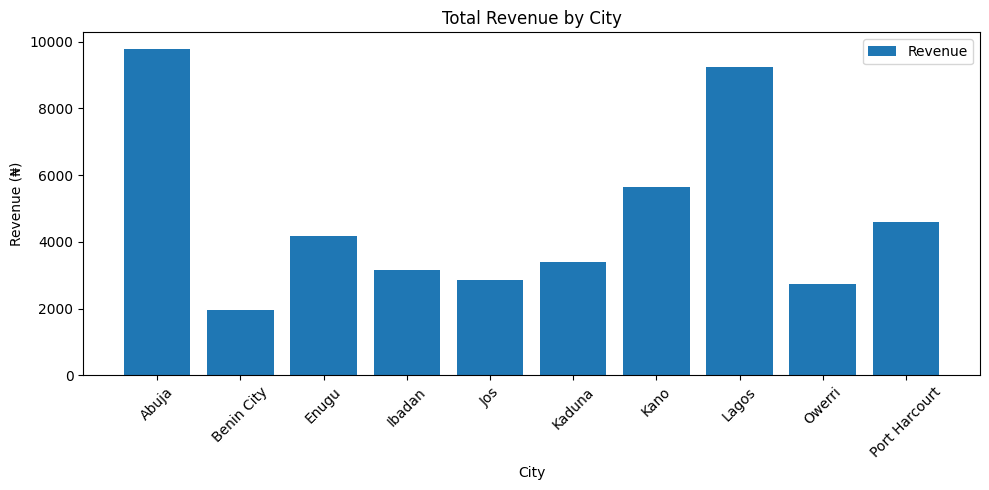

In [ ]:
# Chart 1 — Total revenue by city (Barchart):

fig, ax = plt.subplots(figsize=(10, 5))

# Prepare data
revenue_by_city = df.groupby("city")["total_amount"].sum()

# Plot
ax.bar(revenue_by_city.index, revenue_by_city.values, label="Revenue")

# Labels
ax.set_title("Total Revenue by City")
ax.set_xlabel("City")
ax.set_ylabel("Revenue (₦)")
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

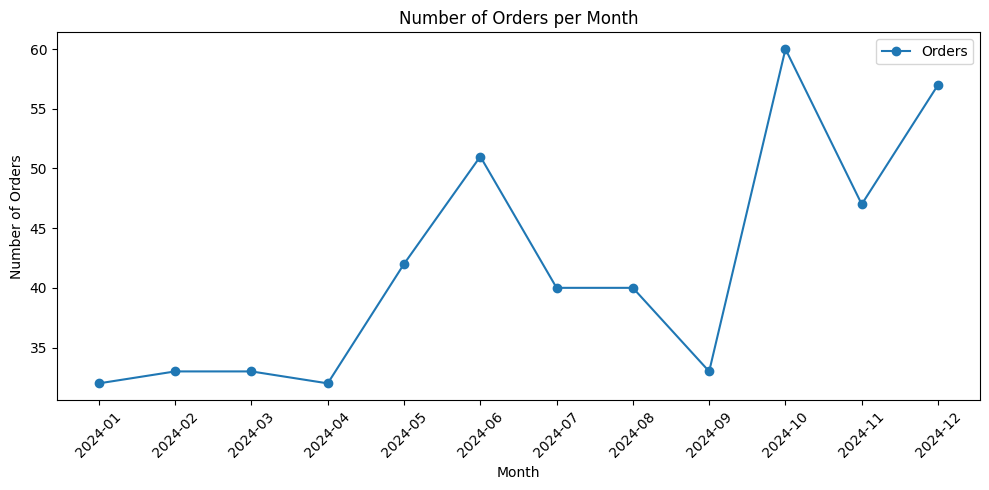

In [ ]:
# Chart 2 — Orders per month (Line chart):

fig, ax = plt.subplots(figsize=(10, 5))

# Prepare data
df["order_date"] = pd.to_datetime(df["order_date"])  # ensure datetime
df["month"] = df["order_date"].dt.to_period("M")     # better month format (YYYY-MM)

orders_per_month = df["month"].value_counts().sort_index()

# Convert index to string so labels show nicely
orders_per_month.index = orders_per_month.index.astype(str)

# Plot
ax.plot(orders_per_month.index, orders_per_month.values, marker="o", label="Orders")

# Labels
ax.set_title("Number of Orders per Month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Orders")
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

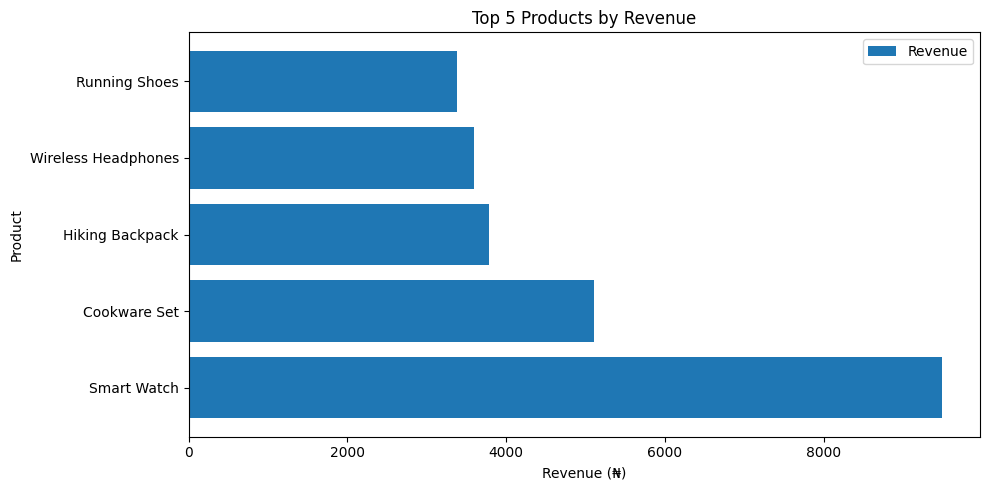

In [ ]:
# Chart 3 — Top 5 products by revenue (horizontal bar chart):

fig, ax = plt.subplots(figsize=(10, 5))

# Prepare data
top_products = (
    df.groupby("product_name")["total_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

# Plot
ax.barh(top_products.index, top_products.values, label="Revenue")

# Labels
ax.set_title("Top 5 Products by Revenue")
ax.set_xlabel("Revenue (₦)")
ax.set_ylabel("Product")
ax.legend()

plt.tight_layout()
plt.show()

## Question 3.3 — Code ⭐ Challenge — Multi-Panel Dashboard

Create a **single figure with 4 subplots** in a 2×2 layout showing:
1. Revenue by category (bar chart)
2. Orders by sales channel (bar chart)  
3. Distribution of `unit_price` values (histogram with 20 bins)
4. Monthly revenue trend (line chart)

Requirements:
- Overall figure title: `"DataTrove 2024 — Sales Overview"`
- Each subplot must have a title and axis labels
- Save the figure as `task3b_sales_overview.png`

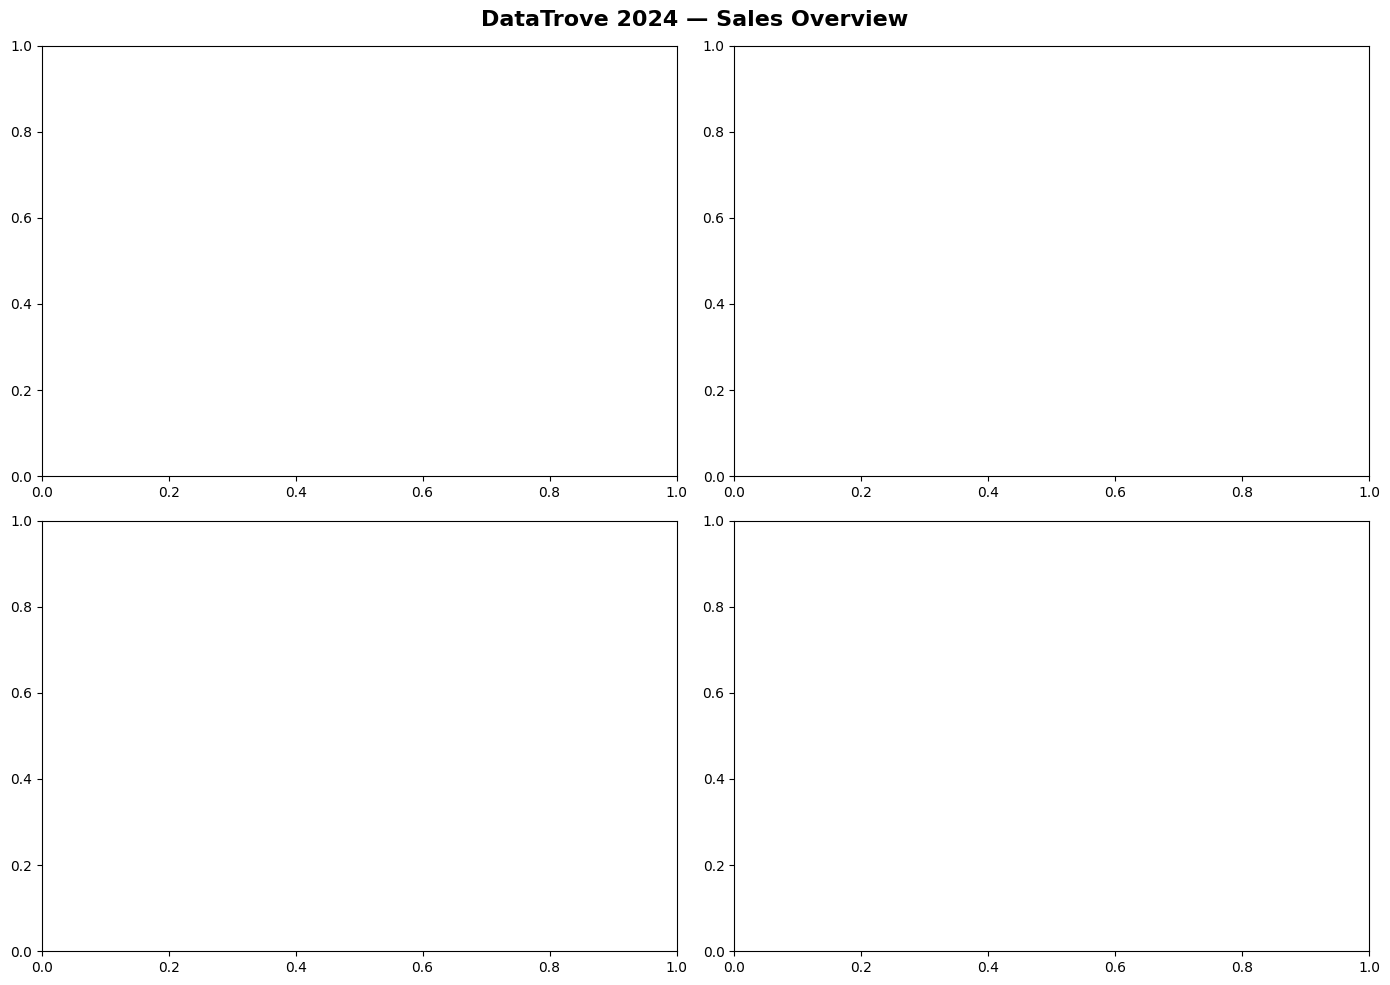

Saved as task3c_sales_overview.png


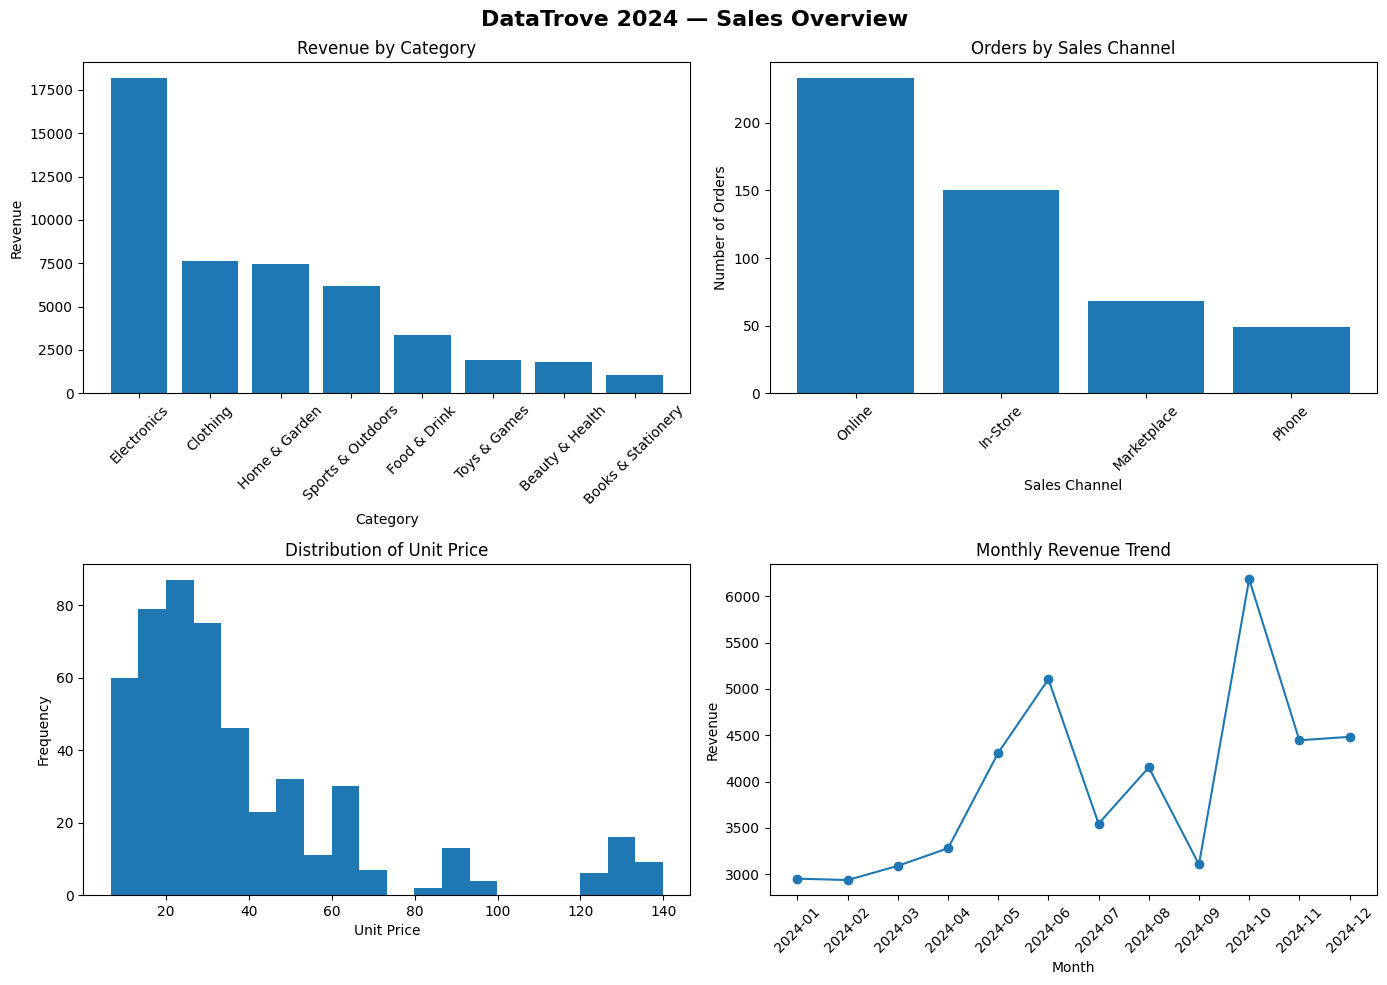

Saved as task3c_sales_overview.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("DataTrove 2024 — Sales Overview", fontsize=16, fontweight='bold')

# axes[0, 0] — Revenue by category:

# axes[0, 1] — Orders by sales channel:

# axes[1, 0] — unit_price distribution:

# axes[1, 1] — Monthly revenue trend:

# Chart Dashboard — 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("DataTrove 2024 — Sales Overview", fontsize=16, fontweight='bold')

# Ensure correct data types
df["order_date"] = pd.to_datetime(df["order_date"])

# -------------------------------
# axes[0, 0] — Revenue by category
revenue_by_category = df.groupby("category")["total_amount"].sum().sort_values(ascending=False)

axes[0, 0].bar(revenue_by_category.index, revenue_by_category.values)
axes[0, 0].set_title("Revenue by Category")
axes[0, 0].set_xlabel("Category")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].tick_params(axis='x', rotation=45)

# -------------------------------
# axes[0, 1] — Orders by sales channel
orders_by_channel = df["sales_channel"].value_counts()

axes[0, 1].bar(orders_by_channel.index, orders_by_channel.values)
axes[0, 1].set_title("Orders by Sales Channel")
axes[0, 1].set_xlabel("Sales Channel")
axes[0, 1].set_ylabel("Number of Orders")
axes[0, 1].tick_params(axis='x', rotation=45)

# -------------------------------
# axes[1, 0] — unit_price distribution
axes[1, 0].hist(df["unit_price"], bins=20)
axes[1, 0].set_title("Distribution of Unit Price")
axes[1, 0].set_xlabel("Unit Price")
axes[1, 0].set_ylabel("Frequency")

# -------------------------------
# axes[1, 1] — Monthly revenue trend
df["month"] = df["order_date"].dt.to_period("M")
monthly_revenue = df.groupby("month")["total_amount"].sum().sort_index()

monthly_revenue.index = monthly_revenue.index.astype(str)

axes[1, 1].plot(monthly_revenue.index, monthly_revenue.values, marker="o")
axes[1, 1].set_title("Monthly Revenue Trend")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Revenue")
axes[1, 1].tick_params(axis='x', rotation=45)

# -------------------------------
plt.tight_layout()
plt.savefig('task3c_sales_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved as task3c_sales_overview.png")

---
# Part 4 — seaborn

*seaborn builds on matplotlib and makes it much easier to create beautiful, statistically informative charts. It is the go-to library for exploratory data analysis and is designed to work directly with pandas DataFrames.*

## Question 4.1 — Written

What does seaborn add on top of matplotlib?  
Name **four** chart types that seaborn is particularly good at and describe when you would use each one in a data analysis context.

## What does seaborn add on top of matplotlib?
seaborn makes plotting easier and faster
it comes with better default styles
it works directly with pandas DataFrames
it includes built-in statistical visualisations

## Four seaborn chart types and when to use them:
countplot → used to count how many times each category appears (e.g. orders per sales channel)
boxplot → used to show distribution, median, and outliers (e.g. price spread across categories)
histplot → used to show distribution of numerical data (e.g. unit_price distribution)
heatmap → used to show relationships between variables (e.g. correlation matrix)

## Question 4.2 — Code — Three Seaborn Charts

Using seaborn and the DataTrove dataset, create the following. Every chart must be properly titled and labelled.

**Chart 1 — `sns.countplot`:** Number of orders per sales channel, coloured by `return_flag`

**Chart 2 — `sns.boxplot`:** Distribution of `total_amount` per category  
*(This reveals spread, median, and outliers — very useful for spotting data quality issues)*

**Chart 3 — `sns.heatmap`:** Correlation matrix of numerical columns  
(`quantity`, `unit_price`, `discount_pct`, `total_amount`)  
*Hint: use `df[cols].corr()` to compute the correlation matrix first*

In [12]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_theme(style="whitegrid")

# ✅ CORRECT PATH (go up one folder, then into dataset)
DATA_PATH = "../dataset/datatrove_sales_2024.csv"

# Load dataset
df = pd.read_csv(DATA_PATH)

# Convert date column
df["order_date"] = pd.to_datetime(df["order_date"])

# Ensure numeric columns are correct
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce")
df["discount_pct"] = pd.to_numeric(df["discount_pct"], errors="coerce")
df["total_amount"] = pd.to_numeric(df["total_amount"], errors="coerce")

# Quick check
df.head()

,order_id,order_date,city,category,product_name,quantity,unit_price,discount_pct,total_amount,customer_id,return_flag,sales_channel,payment_method
0,DT-20240069,2024-01-01,Ibadan,Home & Garden,Table Lamp,1,24.03,0,24.03,CUST-0139,N,Online,Cash
1,DT-20240027,2024-01-02,Abuja,Home & Garden,Table Lamp,4,26.68,0,106.72,CUST-0034,N,Online,Card
2,DT-20240073,2024-01-02,Abuja,Beauty & Health,Face Moisturiser,4,18.72,0,74.88,CUST-0077,N,In-Store,Bank Transfer
3,DT-20240215,2024-01-03,Enugu,Electronics,USB-C Hub,4,25.03,15,85.10,CUST-0053,N,In-Store,Bank Transfer
4,DT-20240362,2024-01-04,Port Harcourt,Electronics,Wireless Headphones,5,49.33,0,246.65,CUST-0031,N,Online,Cash


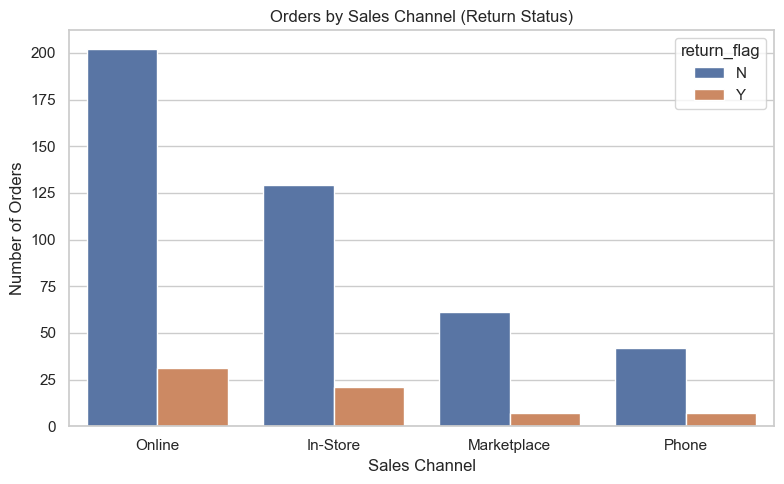

In [13]:
# Chart 1 — Countplot (orders by sales channel, coloured by return_flag)

fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(
    data=df,
    x="sales_channel",
    hue="return_flag",
    ax=ax
)

ax.set_title("Orders by Sales Channel (Return Status)")
ax.set_xlabel("Sales Channel")
ax.set_ylabel("Number of Orders")

plt.tight_layout()
plt.show()

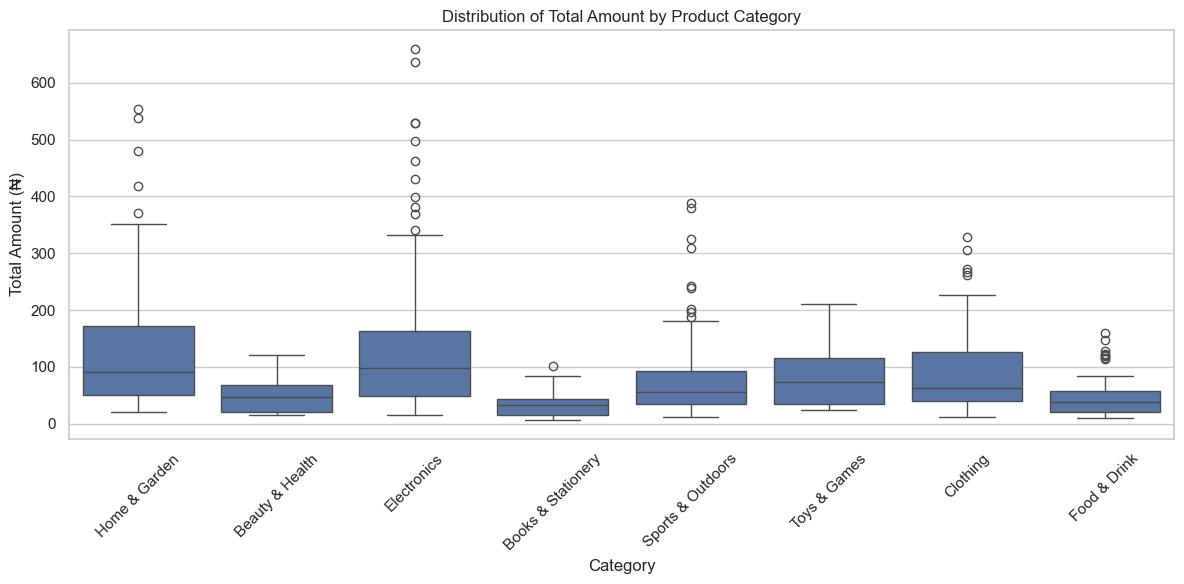

In [14]:
# Chart 2 — boxplot (total_amount distribution per category):

fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="category",
    y="total_amount",
    ax=ax
)

ax.set_title("Distribution of Total Amount by Product Category")
ax.set_xlabel("Category")
ax.set_ylabel("Total Amount (₦)")
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

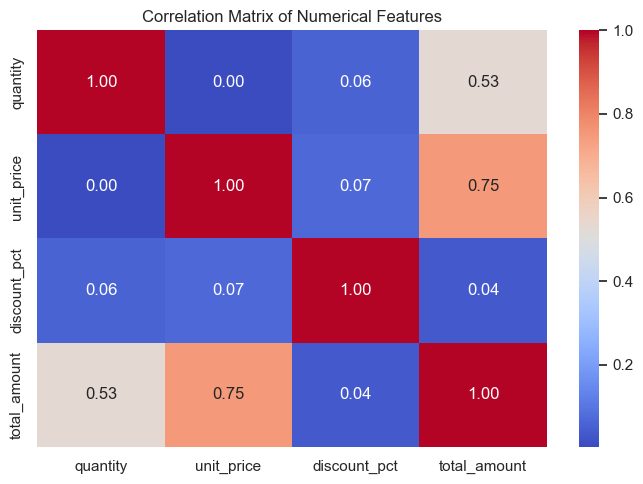

In [15]:
# Chart 3 — heatmap (correlation matrix):

fig, ax = plt.subplots(figsize=(7, 5))

corr = df[["quantity", "unit_price", "discount_pct", "total_amount"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=ax
)

ax.set_title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

## Question 4.3 — Code ⭐ Challenge — Visual EDA Report

Create a seaborn-based exploratory data analysis report of the DataTrove dataset.  
It must include **at least 5 different chart types** that together tell a story about the data.

After **each chart**, write a markdown cell with **2–3 sentences** interpreting:
- What the chart shows
- What it might mean for the business

Think like an analyst presenting findings to Promise Ekeh — what would be most useful to know?

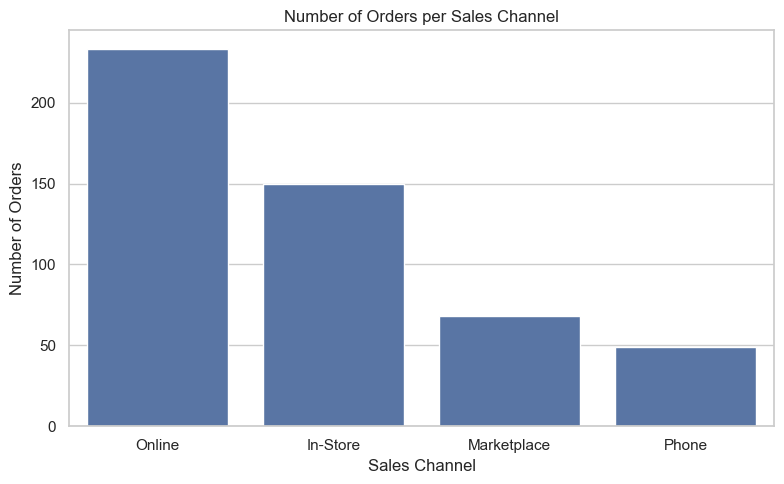

In [16]:
# Chart 1: Orders per Sales Channel (Countplot)

fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(data=df, x="sales_channel", ax=ax)

ax.set_title("Number of Orders per Sales Channel")
ax.set_xlabel("Sales Channel")
ax.set_ylabel("Number of Orders")

plt.tight_layout()
plt.show()

**Interpretation:** 
This chart shows how orders are distributed across the different sales channels. It helps identify the most commonly used channel by customers. If one channel dominates, it suggests where DataTrove should focus marketing and operational improvements.

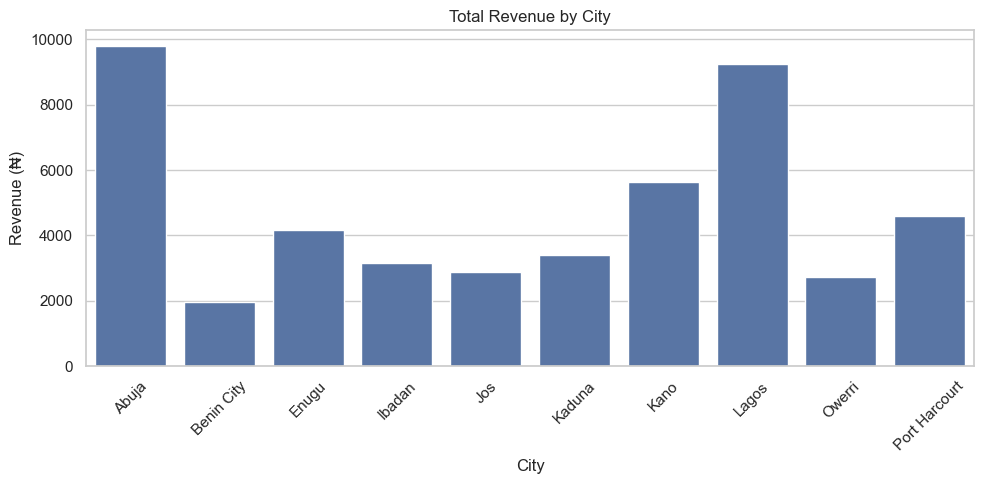

In [17]:
# Chart 2: Total Revenue by City (Barplot)

city_revenue = df.groupby("city")["total_amount"].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=city_revenue, x="city", y="total_amount", ax=ax)

ax.set_title("Total Revenue by City")
ax.set_xlabel("City")
ax.set_ylabel("Revenue (₦)")
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Interpretation:** 
This chart compares total revenue generated by each city. It 
shows the strongest and weakest performing locations. This is useful for regional strategy, such as expanding in high-performing cities or improving sales in low-performing ones.

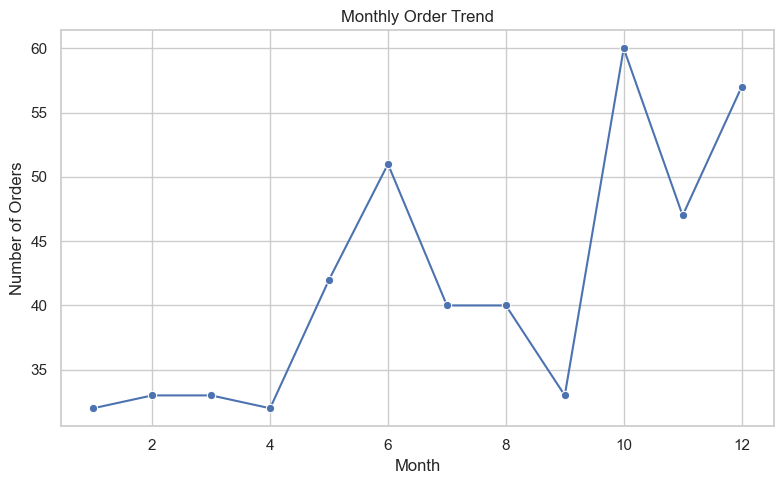

In [19]:
# Chart 3: Monthly Order Trend (Lineplot)

# ensure correct datetime conversion
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

# create month safely
df["month"] = df["order_date"].dt.month

# drop rows where month is missing (just in case)
df_clean = df.dropna(subset=["month"])

# group safely
monthly_orders = df_clean.groupby("month")["order_id"].count().reset_index()

# plot
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=monthly_orders,
    x="month",
    y="order_id",
    marker="o",
    ax=ax
)

ax.set_title("Monthly Order Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Orders")

plt.tight_layout()
plt.show()

**Interpretation:** 
This chart shows how order volume changes across the months. It helps identify seasonal peaks or drops in demand. This insight is useful for planning inventory and marketing campaigns.

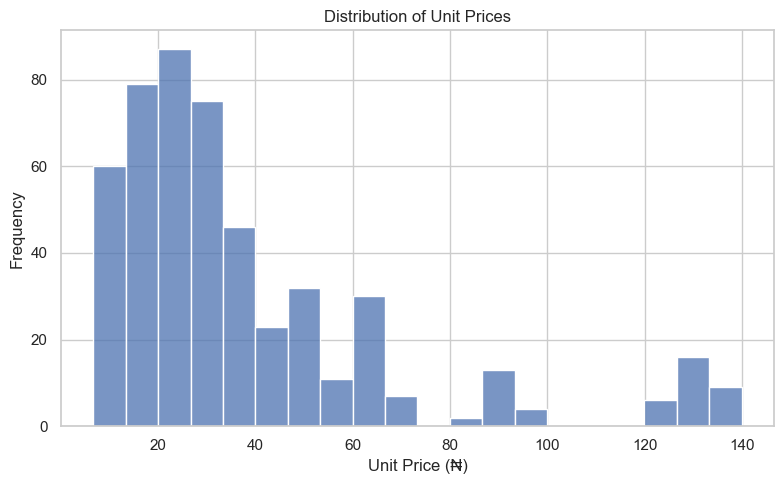

In [20]:
# Chart 4: Distribution of Unit Price (Histogram)

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(data=df, x="unit_price", bins=20, ax=ax)

ax.set_title("Distribution of Unit Prices")
ax.set_xlabel("Unit Price (₦)")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**Interpretation:** 
This chart shows how product prices are distributed across all orders. It helps identify whether most products are low-cost, mid-range, or high-end. This is useful for understanding customer purchasing power and pricing strategy.

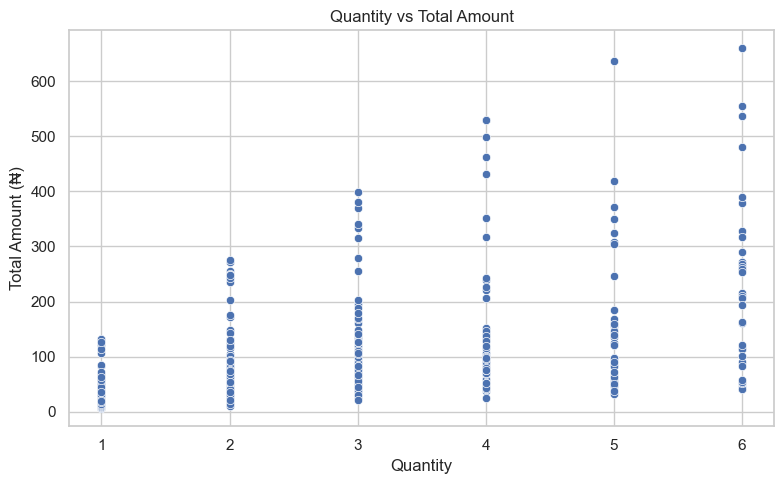

In [21]:
# Chart 5: Relationship between Quantity and Total Amount (Scatterplot)

fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(data=df, x="quantity", y="total_amount", ax=ax)

ax.set_title("Quantity vs Total Amount")
ax.set_xlabel("Quantity")
ax.set_ylabel("Total Amount (₦)")

plt.tight_layout()
plt.show()

**Interpretation:** 
This chart shows the relationship between quantity purchased and total order value. It helps determine whether higher quantities consistently lead to higher revenue. It can also reveal pricing inconsistencies or outliers in the dataset.

---
# ✅ Submission Checklist

Before pushing to GitHub, confirm every item:

- [ ] Setup cell runs with no errors and all 4 library versions print
- [ ] **Part 1 (NumPy)** — all questions answered, challenge attempted
- [ ] **Part 2 (pandas)** — `datatrove_sales_2024.csv` loaded, all 10 exploration questions answered, challenge attempted
- [ ] **Part 3 (matplotlib)** — 3 individual charts created, 2×2 dashboard saved as `task3c_sales_overview.png`
- [ ] **Part 4 (seaborn)** — 3 charts created, ⭐ EDA report has 5 charts with written interpretations
- [ ] All code cells run without errors
- [ ] Code is commented throughout
- [ ] `task3c_sales_overview.png` visible in your repo folder
- [ ] Notebook pushed to `datatrove-placement` GitHub repo

---

> *If your charts are rendering correctly and your GroupBy analysis is working, you are ready for Phase 2. That is where the real data cleaning and analysis begins — using everything you have built across Tasks 1, 2, 3A, 3B, and 3C.*

---
*DataTrove Graduate Academy — Phase 1, Task 3C*  
*Issued by: Promise Ekeh, Head of Analytics*  
*Simulated Training Material — For Educational Use Only*